In [1]:
import pandas as pd
df = pd.read_csv("fetal_health.csv")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['fetal_health'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (2126, 22)

Class distribution:
fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

First 3 rows:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0


In [2]:
# Imports
#import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Quick EDA
print("Missing values (total):", df.isnull().sum().sum())
print("\nFeature ranges (min–max):")
print(df.drop('fetal_health', axis=1).agg(['min', 'max']).T)

Missing values (total): 0

Feature ranges (min–max):
                                                      min      max
baseline value                                      106.0  160.000
accelerations                                         0.0    0.019
fetal_movement                                        0.0    0.481
uterine_contractions                                  0.0    0.015
light_decelerations                                   0.0    0.015
severe_decelerations                                  0.0    0.001
prolongued_decelerations                              0.0    0.005
abnormal_short_term_variability                      12.0   87.000
mean_value_of_short_term_variability                  0.2    7.000
percentage_of_time_with_abnormal_long_term_vari...    0.0   91.000
mean_value_of_long_term_variability                   0.0   50.700
histogram_width                                       3.0  180.000
histogram_min                                        50.0  159.000
histogram

In [4]:
# Feature-target split
X = df.drop('fetal_health', axis=1)
y = df['fetal_health'].astype(int)   # cast to int since classes are 1, 2, 3
 
print("Features shape:", X.shape)
print("Target classes:", sorted(y.unique()))

Features shape: (2126, 21)
Target classes: [np.int64(1), np.int64(2), np.int64(3)]


In [5]:
# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples:  {X_test.shape[0]}")
print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

Train samples: 1700
Test samples:  426

Class distribution in test set:
fetal_health
1    332
2     59
3     35
Name: count, dtype: int64


In [6]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Wrap back into DataFrame so column names survive (useful for later inspection)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
print("Scaled feature means (should be ~0):")
print(X_train_scaled.mean().round(4).head())
print("\nScaled feature stds (should be ~1):")
print(X_train_scaled.std().round(4).head())

Scaled feature means (should be ~0):
baseline value         -0.0
accelerations           0.0
fetal_movement          0.0
uterine_contractions   -0.0
light_decelerations    -0.0
dtype: float64

Scaled feature stds (should be ~1):
baseline value          1.0003
accelerations           1.0003
fetal_movement          1.0003
uterine_contractions    1.0003
light_decelerations     1.0003
dtype: float64


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
 
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report
)

In [8]:
# Define all 5 models with sensible defaults
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, random_state=42, class_weight='balanced'
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7
    ),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=42, class_weight='balanced'
    ),
}
 
print(f"Ready to train {len(models)} models.")
for name in models:
    print(f"  • {name}")

Ready to train 5 models.
  • Logistic Regression
  • Decision Tree
  • K-Nearest Neighbors
  • Naive Bayes
  • Random Forest


In [9]:
# Train all models — takes ~5-10 seconds total
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"✓ {name} trained")

✓ Logistic Regression trained
✓ Decision Tree trained
✓ K-Nearest Neighbors trained
✓ Naive Bayes trained
✓ Random Forest trained


In [10]:
# Compute all 6 metrics for each trained model
results = []
 
for name, model in trained_models.items():
    # Predictions: class labels AND class probabilities (needed for AUC)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    # 6 metrics — multi-class averaging strategy explained below
    accuracy  = accuracy_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)
    mcc       = matthews_corrcoef(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc,
    })
 
results_df = pd.DataFrame(results)
print("Done. Metrics computed for all 5 models.")

Done. Metrics computed for all 5 models.


In [11]:
# Display comparison table with best value per metric highlighted in green
(results_df
.set_index("Model")
.style
.highlight_max(axis=0, color='#d1fae5')
.format('{:.4f}'))

,Accuracy,AUC,Precision,Recall,F1,MCC
Model,,,,,,
Logistic Regression,0.8568,0.9602,0.7406,0.8497,0.7798,0.6868
Decision Tree,0.8873,0.8786,0.8150,0.8496,0.8268,0.7188
K-Nearest Neighbors,0.8709,0.9563,0.8090,0.6900,0.7374,0.6168
Naive Bayes,0.8099,0.8759,0.6500,0.7011,0.6569,0.5737
Random Forest,0.9319,0.9812,0.8920,0.8625,0.8764,0.8097


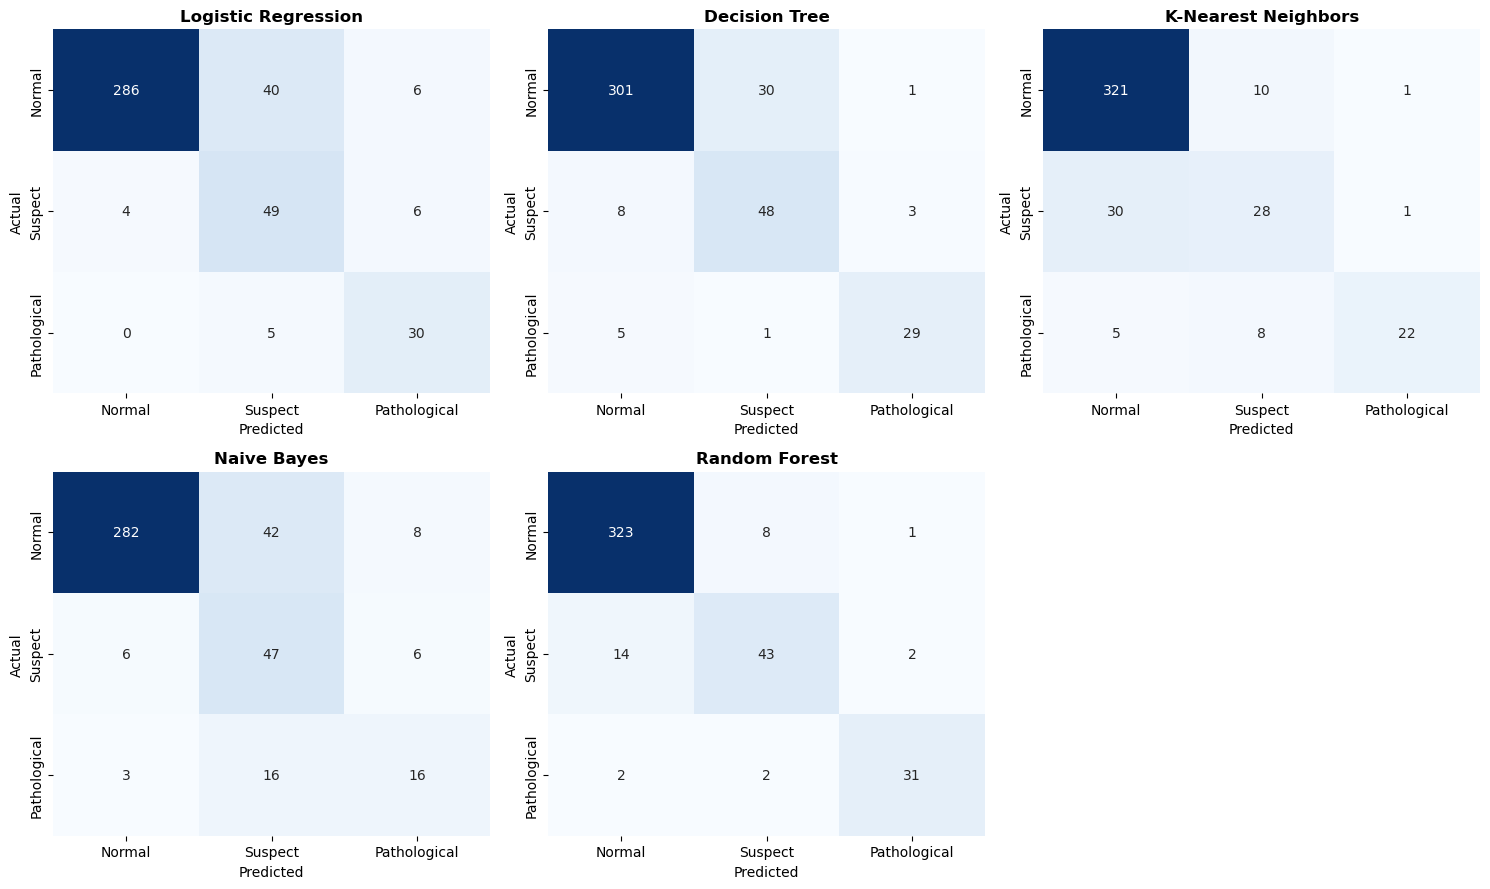

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
 
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
 
class_labels = ['Normal', 'Suspect', 'Pathological']
 
for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[idx], cbar=False
    )
    axes[idx].set_title(f"{name}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
 
# Hide the empty 6th subplot
axes[5].axis('off')
 
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
import os
 
# Create the model/ subfolder
os.makedirs('model', exist_ok=True)
 
# Save the scaler (needed to preprocess new data in the app)
with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
 
# Save each trained model with a clean filename
filename_map = {
    "Logistic Regression": "logistic_regression",
    "Decision Tree": "decision_tree",
    "K-Nearest Neighbors": "knn",
    "Naive Bayes": "naive_bayes",
    "Random Forest": "random_forest",
}
for name, model in trained_models.items():
    slug = filename_map[name]
    filepath = f'model/{slug}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ Saved {filepath}")
 
print("\nAll models saved.")

✓ Saved model/logistic_regression.pkl
✓ Saved model/decision_tree.pkl
✓ Saved model/knn.pkl
✓ Saved model/naive_bayes.pkl
✓ Saved model/random_forest.pkl

All models saved.


In [15]:
# Save the test set (with the target column) as a CSV — this ships with the repo
# so evaluators can upload it into your Streamlit app to reproduce the results.
test_df = X_test.copy()
test_df['fetal_health'] = y_test.values
test_df.to_csv('test_data.csv', index=False)
print(f"Saved test_data.csv with {len(test_df)} rows and {len(test_df.columns)} columns")
print("First 3 rows:")
test_df.head(3)

Saved test_data.csv with 426 rows and 22 columns
First 3 rows:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
1354,132.0,0.005,0.000,0.002,0.003,0.0,0.0,25.0,1.5,0.0,...,76.0,168.0,4.0,2.0,141.0,138.0,140.0,16.0,1.0,1
1028,135.0,0.011,0.000,0.005,0.002,0.0,0.0,25.0,2.5,0.0,...,89.0,178.0,5.0,2.0,143.0,145.0,147.0,10.0,0.0,1
637,143.0,0.007,0.018,0.000,0.000,0.0,0.0,44.0,1.3,0.0,...,80.0,181.0,6.0,0.0,146.0,147.0,148.0,5.0,0.0,1
